# Exploratory Analysis of Architectural Ratings

This notebook documents the analysis pipeline for the five rating items (*Hominess, Naturalness, Personalness, Beauty, Approachability*), including data preparation, exploratory checks, dimensionality reduction (PCA), and group comparisons by **Category**.


# Data Preparation

## Loading libraries

In [7]:
# import the libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Load and inspect dataset

In [8]:
# load the data
file_path = "Data_exp1.xlsx"  
df = pd.read_excel(file_path)
# quick check
print(df.info())
print(df.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9833 entries, 0 to 9832
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   ImageNumber      9833 non-null   int64 
 1   Dimension        9833 non-null   object
 2   PredHominess     9833 non-null   object
 3   Hominess         9833 non-null   int64 
 4   Naturalness      9833 non-null   int64 
 5   Personalness     9833 non-null   int64 
 6   Beauty           9833 non-null   int64 
 7   Approachability  9833 non-null   int64 
 8   Participant      9833 non-null   int64 
dtypes: int64(7), object(2)
memory usage: 691.5+ KB
None
   ImageNumber Dimension PredHominess  Hominess  Naturalness  Personalness  \
0           55   Ceiling         Plus         4            6             4   
1          138   Ceiling        Minus         3            5             1   
2          107  Lighting        Minus         2            3             1   
3           51   Ceiling      

We can see that this data frame has 9 variables. All of them are numerical except Dimension and PredHomines.

In [9]:
# check the size of the data frame
size_dim = df.shape
print(f"The size of this data frame: {size_dim}")
# check if there are missing values
missing_rows = df.isnull().any(axis=1).sum()
print(f"Number of rows with missing values: {missing_rows}")

The size of this data frame: (9833, 9)
Number of rows with missing values: 0


In [10]:
# Count unique participants
n_participants = df["Participant"].nunique()
print("Number of participants:", n_participants)
df['Participant'].value_counts()

Number of participants: 62


Participant
32    160
2     160
34    160
35    160
36    160
     ... 
28    160
29    160
1     156
60    121
17    116
Name: count, Length: 62, dtype: int64

This data frame has 9833 rows without missing values. Most of the participants completed all 160 trials except number 1(156 trials), 60(121 trials), and 17(116 trials).

Each picture was categorized as either hominess Plus or hominess Negative. Within the Negative category, there were four subcategories: Ceiling, Lighting, Biophilic, and Combined. Each subcategory involved the removal of one dimension, except for the Combined condition, in which three dimensions were removed simultaneously. For analysis, we merged these conditions into a single categorical variable. Pictures labeled as hominess Plus were coded as Plus, whereas pictures labeled as hominess Negative were further classified according to their specific subcategory (Ceiling, Lighting, Biophilic, or Combined).

In [11]:
df['Category'] = np.where(df['PredHominess'] == 'Plus', 'Plus', df['Dimension'])
df.drop(columns=['Dimension'], inplace=True)
df['Category'].value_counts()

Category
Plus         4919
Combined     1233
Ceiling      1231
Lighting     1228
Biophilic    1222
Name: count, dtype: int64

In [12]:
mapping = {
    'Plus': 'Combined+',
    'Ceiling': 'Ceiling-',
    'Lighting': 'Lighting-',
    'Biophilic': 'Biophilic-',
    'Combined': 'Combined-'
}
df['Category'] = df['Category'].map(mapping)
df['Category'].value_counts()

Category
Combined+     4919
Combined-     1233
Ceiling-      1231
Lighting-     1228
Biophilic-    1222
Name: count, dtype: int64

# Exploratory analysis

## Distributions of rating variables

We can first check the statistics of the rating columns, then plot their distributions.

In [13]:
rating_cols = ['Hominess', 'Naturalness', 'Personalness', 'Beauty', 'Approachability']
rating_df = df[rating_cols]
# Summary statistics
print(rating_df.describe())

          Hominess  Naturalness  Personalness       Beauty  Approachability
count  9833.000000  9833.000000   9833.000000  9833.000000      9833.000000
mean      4.432320     4.226482      4.107495     4.867589         5.246415
std       1.798574     2.084627      1.925784     1.804851         1.711492
min       1.000000     1.000000      1.000000     1.000000         1.000000
25%       3.000000     2.000000      3.000000     4.000000         4.000000
50%       5.000000     5.000000      4.000000     5.000000         6.000000
75%       6.000000     6.000000      6.000000     6.000000         7.000000
max       7.000000     7.000000      7.000000     7.000000         7.000000


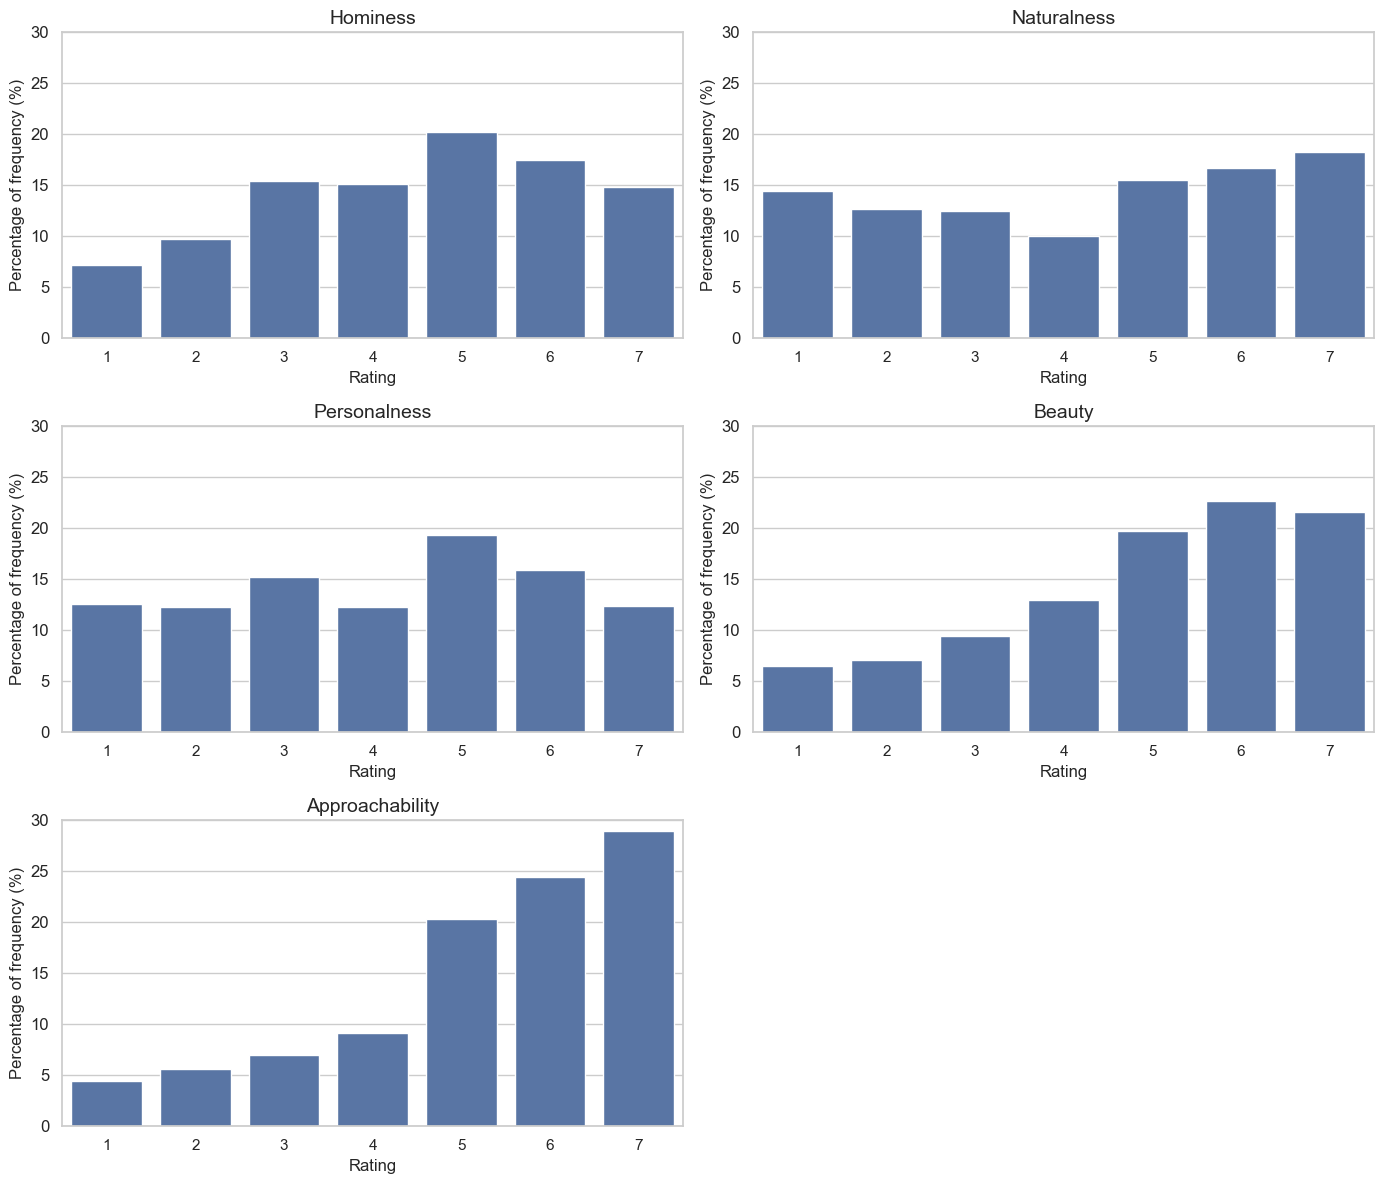

In [14]:
# Set clean academic style
sns.set(style="whitegrid")

plt.figure(figsize=(14, 12))

for i, col in enumerate(rating_cols, 1):
    plt.subplot(3, 2, i)

    # Count frequencies and convert to percentage
    counts = df[col].value_counts().sort_index()

    # Ensure all rating levels appear (1–7)
    counts = counts.reindex([1, 2, 3, 4, 5, 6, 7], fill_value=0)

    percent = counts / counts.sum() * 100


    sns.barplot(
        x=percent.index,          # Rating levels (1–7)
        y=percent.values         # Percentage values
    )

    # Titles and labels
    plt.title(col, fontsize=14)
    plt.ylabel("Percentage of frequency (%)", fontsize=12)
    plt.xlabel("Rating", fontsize=12)
    plt.ylim(0,30)
    plt.yticks(np.arange(0, 35, step=5), fontsize=12)


plt.tight_layout()
plt.show()


## Inter-variable correlations

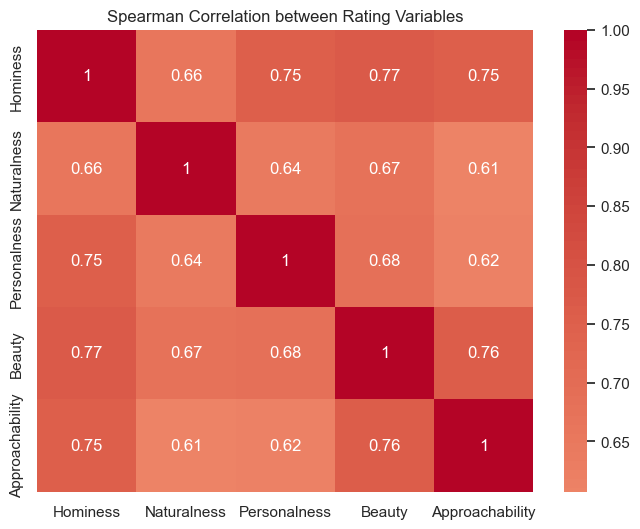

In [15]:
# Spearman correlation
corr = rating_df.corr(method="spearman")
# heatmap
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0)
plt.title("Spearman Correlation between Rating Variables")
plt.show()


The rating variables are highly correlated. So first we need to do dimension reduction. We are interested how many factors they are actually measuring.

## Consistency analysis (Cronbach's alpha)

In [16]:
import pingouin as pg
alpha = pg.cronbach_alpha(data=rating_df)
print("Cronbach’s alpha:", alpha)

Cronbach’s alpha: (0.9162247029571796, array([0.914, 0.919]))


The five rating items showed excellent internal consistency (Cronbach’s α = 0.92, 95% CI [0.914, 0.919]), suggesting that they reflect a common underlying construct.

# Dimensionality Reduction

In [17]:
# load libraries for PCA
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

## PCA

In [18]:
# Standardize variables and run PCA
X_scaled = StandardScaler().fit_transform(rating_df)
pca = PCA()
X_pca = pca.fit_transform(X_scaled)
explained_var = pca.explained_variance_ratio_
cumulative_var = np.cumsum(explained_var)
print("Explained variance ratio:", explained_var)
print("Cumulative explained variance:", cumulative_var)

Explained variance ratio: [0.75616507 0.08884057 0.07382676 0.04314609 0.03802152]
Cumulative explained variance: [0.75616507 0.84500563 0.9188324  0.96197848 1.        ]


### Scree plot

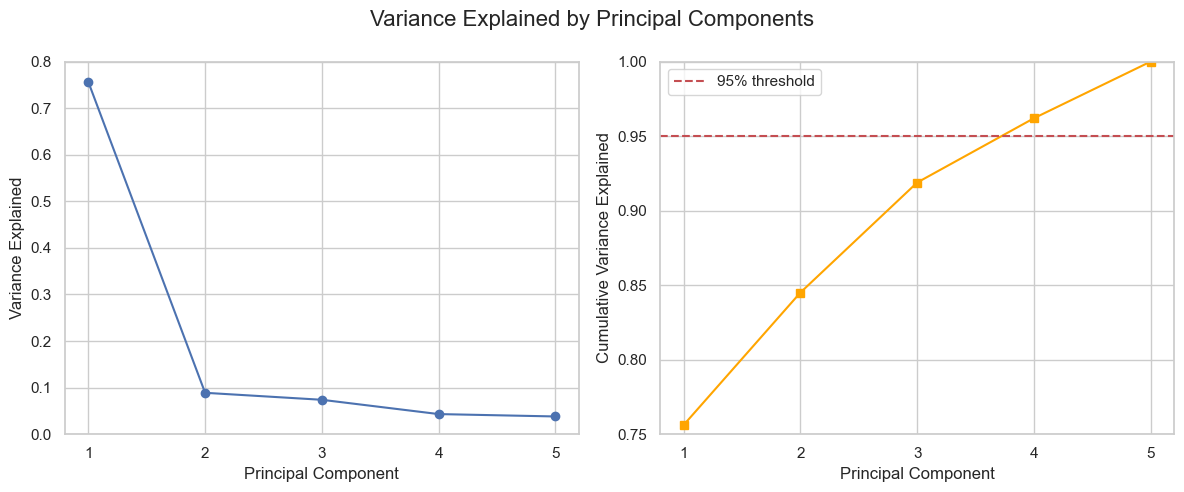

In [19]:
# Create subplots
fig, axes = plt.subplots(1, 2, figsize=(12,5))
# Add a shared title for both subplots
fig.suptitle("Variance Explained by Principal Components", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])

# --- Plot 1: Scree plot ---
axes[0].plot(range(1, len(explained_var)+1), explained_var, marker='o')
axes[0].set_xticks(np.arange(1, len(explained_var)+1, 1))
axes[0].set_xlabel("Principal Component")
axes[0].set_ybound(0, 0.8)
axes[0].set_ylabel("Variance Explained")

# --- Plot 2: Cumulative variance ---
axes[1].plot(range(1, len(cumulative_var)+1), cumulative_var, marker='s', color='orange')
axes[1].axhline(y=0.95, color='r', linestyle='--', label="95% threshold")
axes[1].set_xticks(np.arange(1, len(cumulative_var)+1, 1))
axes[1].set_xlabel("Principal Component")
axes[1].set_ybound(0.75,1)
axes[1].set_ylabel("Cumulative Variance Explained")
axes[1].legend()

plt.tight_layout()
plt.show()


In [20]:
# Get loadings: components_.T scaled by sqrt(eigenvalues)
loadings = pca.components_.T * np.sqrt(pca.explained_variance_)

loading_df = pd.DataFrame(
    loadings,
    index=rating_df.columns,
    columns=[f"PC{i+1}" for i in range(loadings.shape[1])]
)

print(loading_df)


                      PC1       PC2       PC3       PC4       PC5
Hominess         0.911102 -0.075482  0.147956 -0.255143  0.278045
Naturalness      0.816372  0.433367 -0.377993 -0.050090 -0.021074
Personalness     0.847630  0.260644  0.425902  0.081566 -0.160138
Beauty           0.900238 -0.194160 -0.090217  0.352812  0.139137
Approachability  0.869330 -0.380933 -0.121944 -0.130445 -0.259558


Principal component analysis (PCA) revealed that the first component alone explained 75.6% of the variance, while the subsequent components each explained less than 10%. The scree plot suggested a clear one-factor solution. Together with the high internal consistency of the five items (Cronbach’s α = .92), this indicates that the ratings reflect a single underlying construct.

In [21]:
df['mean_rating'] = df[rating_cols].mean(axis=1)
df['PC1_scores'] = X_pca[:, 0]
# save the processed data
df.to_csv("Data_exp1.csv", index=False)

In [22]:
df.head()

,ImageNumber,PredHominess,Hominess,Naturalness,Personalness,Beauty,Approachability,Participant,Category,mean_rating,PC1_scores
0,55,Plus,4,6,4,4,6,1,Combined+,4.8,0.194531
1,138,Minus,3,5,1,3,5,1,Ceiling-,3.4,-1.464231
2,107,Minus,2,3,1,1,3,1,Lighting-,2.0,-3.163054
3,51,Plus,3,2,2,3,5,1,Combined+,3.0,-1.842077
4,35,Plus,4,5,4,5,6,1,Combined+,4.8,0.249649


In [23]:
corr = np.corrcoef(df['mean_rating'], df['PC1_scores'])[0, 1]
print("Correlation between mean rating and PC1:", corr)

Correlation between mean rating and PC1: 0.9993973795304417


# Parametric tests
## ANOVA

To test how the architectural factors affect our feeling about the rooms.

In [24]:
df_subject = df.groupby(["Participant", "Category"])["mean_rating"].mean().reset_index()
df_subject.groupby(["Category"])["mean_rating"].agg(['mean', 'std'])

,mean,std
Category,,
Biophilic-,4.118768,0.714325
Ceiling-,4.617245,0.773094
Combined+,5.402562,0.656480
Combined-,2.670833,0.716990
Lighting-,3.591039,0.812577


In [25]:
# Perform RM-anova
aov_table = pg.rm_anova(dv="mean_rating", within="Category", subject="Participant", data=df_subject, detailed=True)
print(aov_table)

     Source          SS   DF         MS           F         p-unc  \
0  Category  264.376754    4  66.094188  295.324648  3.119838e-92   
1     Error   54.607640  244   0.223802         NaN           NaN   

      p-GG-corr       ng2       eps sphericity   W-spher       p-spher  
0  9.159783e-66  0.614993  0.704149      False  0.461726  6.316636e-07  
1           NaN       NaN       NaN        NaN       NaN           NaN  


## Post hoc

In [26]:
# Run pairwise t-tests
posthoc = pg.pairwise_tests(
    dv="mean_rating",
    within="Category",
    subject="Participant",
    padjust="bonf",
    data=df_subject
)

# Compute mean difference and 95% CI for each pair using pg.ttest
ci_rows = []

for _, row in posthoc.iterrows():
    A = row["A"]
    B = row["B"]

    # Extract paired data for conditions A and B
    data_A = df_subject.loc[df_subject["Category"] == A, "mean_rating"]
    data_B = df_subject.loc[df_subject["Category"] == B, "mean_rating"]

    # Paired t-test with CI
    res = pg.ttest(data_A, data_B, paired=True)

    # Mean difference (A - B)
    mean_diff = data_A.mean() - data_B.mean()

    # 95% CI of the difference (pg returns it as an interval-like object or tuple)
    ci_low, ci_high = res["CI95%"].iloc[0]

    ci_rows.append({
        "A": A,
        "B": B,
        "mean_diff": mean_diff,
        "CI95%_lower": ci_low,
        "CI95%_upper": ci_high
    })

ci_df = pd.DataFrame(ci_rows)

# Merge CI and mean difference back into the original posthoc table
posthoc = posthoc.merge(ci_df, on=["A", "B"])


In [27]:
# Keep only the essential statistics
posthoc_clean = posthoc[[
    "A",
    "B",
    "mean_diff",
    "CI95%_lower",
    "CI95%_upper",
    "T",
    "dof",
    "p-corr",
    "hedges"
]].copy()

# Add a significance flag based on Bonferroni-corrected p-value
alpha = 0.05
posthoc_clean["significant"] = posthoc_clean["p-corr"] < alpha

posthoc_clean

,A,B,mean_diff,CI95%_lower,CI95%_upper,T,dof,p-corr,hedges,significant
0,Biophilic-,Ceiling-,-0.498476,-0.66,-0.33,-6.087437,61.0,8.328562e-07,-0.665608,True
1,Biophilic-,Combined+,-1.283794,-1.43,-1.13,-17.239253,61.0,3.968826e-24,-1.859857,True
2,Biophilic-,Combined-,1.447936,1.29,1.60,18.437643,61.0,1.260443e-25,2.010757,True
3,Biophilic-,Lighting-,0.527729,0.36,0.69,6.458758,61.0,1.955466e-07,0.685565,True
4,Ceiling-,Combined+,-0.785318,-0.93,-0.64,-10.911926,61.0,5.694276e-15,-1.088291,True
5,Ceiling-,Combined-,1.946412,1.76,2.13,21.336565,61.0,5.549265e-29,2.594555,True
6,Ceiling-,Lighting-,1.026205,0.85,1.20,11.507932,61.0,6.310342e-16,1.285976,True
7,Combined+,Combined-,2.731730,2.52,2.95,25.241808,61.0,5.480704e-33,3.949515,True
8,Combined+,Lighting-,1.811523,1.61,2.01,18.071658,61.0,3.554474e-25,2.437325,True
9,Combined-,Lighting-,-0.920207,-1.04,-0.80,-14.761370,61.0,8.426651e-21,-1.193485,True


## Plots

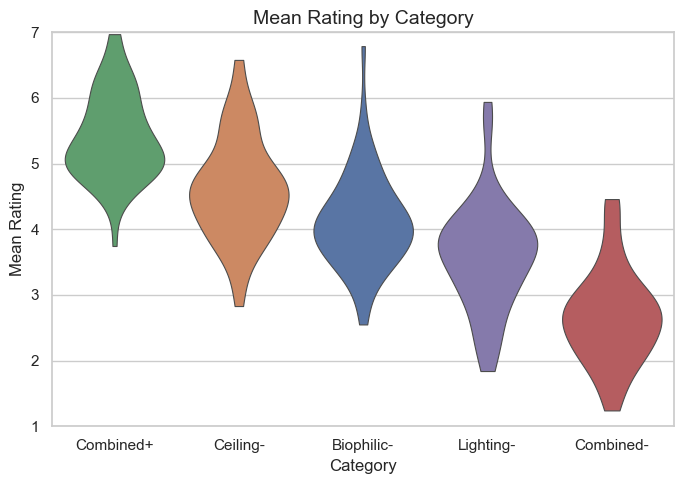

In [31]:
# Plot Category distributions (violin) + means with 95% CI (points)
order=['Combined+', 'Ceiling-', 'Biophilic-', 'Lighting-', 'Combined-']
plt.figure(figsize=(7, 5))

# Violin plot for the distribution of participant-level mean ratings
sns.violinplot(
    x="Category",
    y="mean_rating",
    hue='Category',
    data=df_subject,
    order=order,
    inner=None,      # Do not draw inner boxplot or points
    cut=0,           # Do not extend beyond the data range
    linewidth=0.8
)

plt.ylabel("Mean Rating", fontsize=12)
plt.xlabel("Category", fontsize=12)
plt.ylim(1,7)
plt.title("Mean Rating by Category", fontsize=14)

plt.tight_layout()
plt.show()


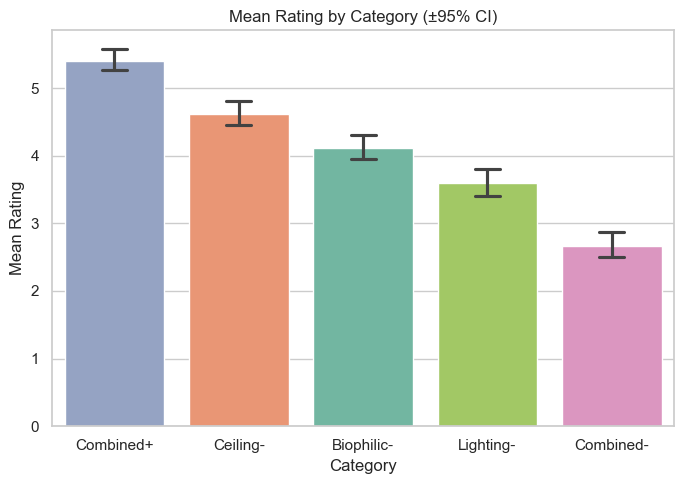

In [32]:
# --- Plot Category means with 95% CI ---

order = ["Combined+", "Ceiling-", "Biophilic-", "Lighting-", "Combined-"]

plt.figure(figsize=(7,5))
sns.barplot(x="Category", y="mean_rating", hue="Category", data=df_subject,
            order=order, palette="Set2", capsize=0.2, errorbar=('ci', 95), legend=False)
plt.ylabel("Mean Rating")
plt.xlabel("Category")
plt.title("Mean Rating by Category (±95% CI)")
plt.tight_layout()
plt.show()


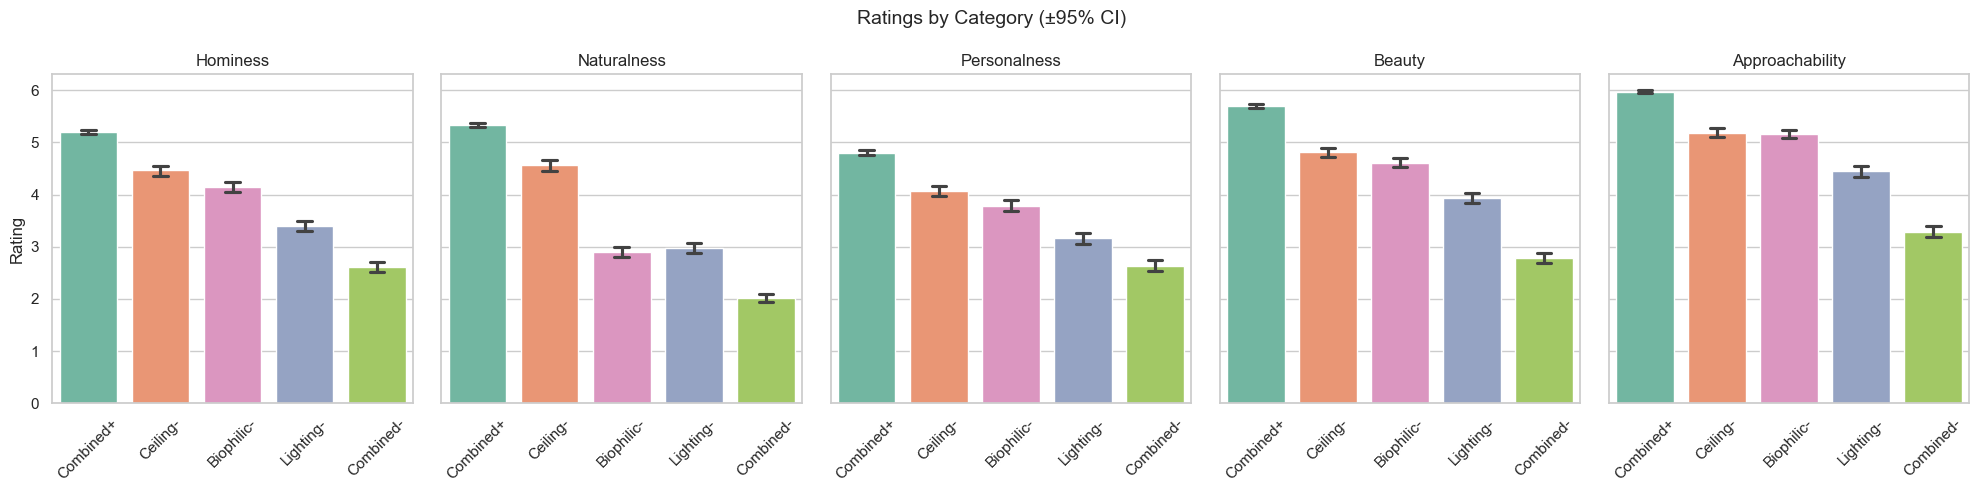

In [33]:
fig, axes = plt.subplots(1, 5, figsize=(20, 5), sharey=True)

for ax, col in zip(axes, rating_cols):
    sns.barplot(
        x="Category", y=col, hue="Category", data=df,
        order=order, palette="Set2", capsize=0.2,
        errorbar=('ci', 95), legend=False, ax=ax
    )
    ax.set_title(col)
    ax.set_xlabel("")
    ax.set_ylabel("Rating" if ax == axes[0] else "")
    ax.tick_params(axis='x', rotation=45)

fig.suptitle("Ratings by Category (±95% CI)", fontsize=14)
plt.tight_layout()
plt.show()

We can observe the significant effect of category. As expected, participants rated the Combined+ images as the most homely and the Combined- images as the least homely. What's more interesting is the order of ratings after removing a certain dimension, i.e, Ceiling- > Biophilic- > Lighting-, suggesting that the three factors make different contributions to the feeling of hominess.